# Pits on Crowns and Flanks: Investigation into the Grain Form of the Layer of Concern


**Original question from Karl:**
My basic question is this:
When an avalanche "breaks on depth hoar", what percentage of time does it break at the interface between the depth hoar and the snow above the depth hoar?  And, what percentage of time does it break at a subtle interface within the depth hoar (usually in the upper 5 to possibly 15 cm of the DH layer)?

In [101]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from snowpyt_mechparams.snowpilot import parse_caaml_directory

In [102]:
# Parse all CAAML files in *data_dir* and return a list of Pit objects.
all_pits = parse_caaml_directory('data')

print(f'Loaded {len(all_pits):,} snow pits')

Loaded 50,278 snow pits


**For pits dug on avalanche crowns and flanks, what is the grain form of the layer of concern?**
- What is the distribution of grain forms
- How often is the grain for Depth Hoar (DH)? 

In [103]:
# Filter to pits dug on avalanche crowns and flanks
crown_and_flank_pits = []

for pit in all_pits:
    if pit.core_info.location.pit_near_avalanche_location == 'crown' or pit.core_info.location.pit_near_avalanche_location == 'flank':
        crown_and_flank_pits.append(pit)


In [104]:
# Extract info from pits on avalanche crowns and flanks
# layer_of_concern is None when no CAAML layer is flagged; grain_form_primary can also be missing.
crown_and_flank_pits_info = []

for pit in crown_and_flank_pits:
    loc = pit.snow_profile.layer_of_concern # layer of concern
    gfp = getattr(loc, "grain_form_primary", None) if loc is not None else None # get primary grain form of LOC
    basic_code = getattr(gfp, "basic_grain_class_code", None) if gfp is not None else None # get basic grain class code of primary grain form of LOC

    crown_and_flank_pits_info.append({
        'pit_id': pit.core_info.pit_id,
        'pit_date': pit.core_info.date,
        'pit_name': pit.core_info.pit_name,
        'operation_name': pit.core_info.user.operation_name,
        'professional': pit.core_info.user.professional,
        'pit_country': pit.core_info.location.country,
        'pit_region': pit.core_info.location.region,
        'pit_near_avalanche_location': pit.core_info.location.pit_near_avalanche_location,
        'LOC_grain_form': basic_code,
        'Comments': pit.core_info.comment
    })

crown_and_flank_pits_info = pd.DataFrame(crown_and_flank_pits_info)
crown_pits = crown_and_flank_pits_info[crown_and_flank_pits_info['pit_near_avalanche_location'] == 'crown']
flank_pits = crown_and_flank_pits_info[crown_and_flank_pits_info['pit_near_avalanche_location'] == 'flank']


In [105]:
## Summary stats

# Number of pits on Crowns and Flanks
print(f'Pits on Crowns: {len(crown_pits)}')
print(f'Pits on Flanks: {len(flank_pits)}')
print(f'Crown and flank pits: {len(crown_and_flank_pits)}')


Pits on Crowns: 795
Pits on Flanks: 399
Crown and flank pits: 1194


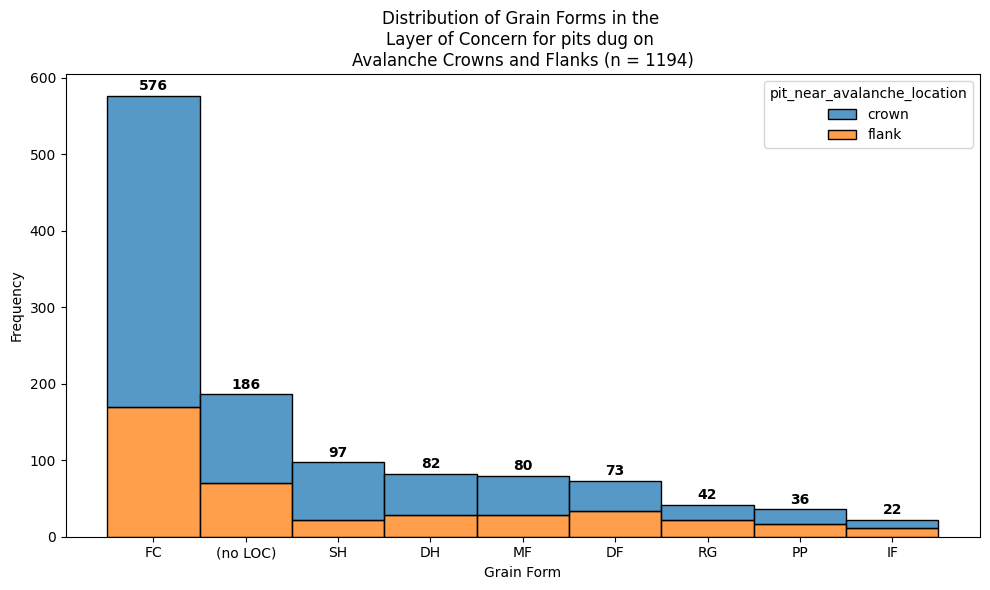

In [114]:
# Plot the frequency of grain forms, stacked by crown/flank (x: most common first)
_plot_df = crown_and_flank_pits_info.copy()
_plot_df['LOC_grain_form'] = _plot_df['LOC_grain_form'].fillna('(no LOC)')
gf_order = _plot_df['LOC_grain_form'].value_counts().index.tolist()
_plot_df['LOC_grain_form'] = pd.Categorical(
    _plot_df['LOC_grain_form'], categories=gf_order, ordered=True
)
hue_order = sorted(_plot_df['pit_near_avalanche_location'].dropna().unique())

fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(
    data=_plot_df,
    x='LOC_grain_form',
    hue='pit_near_avalanche_location',
    hue_order=hue_order,
    multiple='stack',
    ax=ax,
)

bar_totals = _plot_df.groupby('LOC_grain_form', observed=False).size().reindex(
    gf_order, fill_value=0
)
for i, gf in enumerate(gf_order):
    total = int(bar_totals.loc[gf])
    if total <= 0:
        continue
    ax.annotate(
        str(total),
        xy=(i, total),
        xytext=(0, 4),
        textcoords='offset points',
        ha='center',
        fontsize=10,
        fontweight='bold',
    )

ax.set_title(
    'Distribution of Grain Forms in the \nLayer of Concern for pits dug on \nAvalanche Crowns and Flanks (n = %d)'
    % len(crown_and_flank_pits_info)
)
ax.set_xlabel('Grain Form')
ax.set_ylabel('Frequency')
fig.tight_layout()
plt.show()

In [110]:
# Summary table by location
counts_by_gf_and_location = crown_and_flank_pits_info.groupby('pit_near_avalanche_location')['LOC_grain_form'].value_counts().unstack()
# Add row totals
counts_by_gf_and_location.loc['Total'] = counts_by_gf_and_location.sum()
# Add column totals
counts_by_gf_and_location.loc[:, 'Total'] = counts_by_gf_and_location.sum(axis=1)

print(counts_by_gf_and_location)

LOC_grain_form               DF  DH   FC  IF  MF  PP  RG  SH  Total
pit_near_avalanche_location                                        
crown                        40  54  407  11  52  20  20  75    679
flank                        33  28  169  11  28  16  22  22    329
Total                        73  82  576  22  80  36  42  97   1008


In [111]:
# Summary table: crown + flank combined, by grain form (excludes NaN / no LOC)
vc = crown_and_flank_pits_info['LOC_grain_form'].value_counts()
counts_by_gf = pd.DataFrame({'Total': vc})
total = counts_by_gf['Total'].sum()
counts_by_gf['% of Total'] = (counts_by_gf['Total'] / total * 100).round(2)

print(counts_by_gf)

                Total  % of Total
LOC_grain_form                   
FC                576       57.14
SH                 97        9.62
DH                 82        8.13
MF                 80        7.94
DF                 73        7.24
RG                 42        4.17
PP                 36        3.57
IF                 22        2.18


In [112]:
# Locations of pits with DH LOC, sorted by pit_id
dh_avalanche_pits = crown_and_flank_pits_info[crown_and_flank_pits_info['LOC_grain_form'] == 'DH'].sort_values(by='pit_id')
dh_avalanche_pits.to_csv('dh_avalanche_pits.csv', index=False)